# Development model comparison

This committed demonstration uses only the independently invented synthetic cycle history. It compares the non-ML baselines and fixed Ridge candidates on development cycles, selects a Ridge configuration, and renders a report and diagnostic figure. The final 12-cycle holdout remains sealed.

For private analysis, set `CYCLE_FORECAST_DATA_PATH` locally. Never commit private statistics, fingerprints, reports, figures, or executed notebook output.

In [1]:
import os

# Keep the committed notebook on independently invented synthetic data.
# Set the private raw path only in a local session, and never commit its output.
# os.environ["CYCLE_FORECAST_DATA_PATH"] = "data/raw/cycle_history.csv"
os.environ["CYCLE_FORECAST_DATA_PATH"] = "data/synthetic/sample_cycle_history.csv"

In [2]:
from pathlib import Path

from IPython.display import Markdown, display

from cycle_forecast.data import build_cycle_dataset, load_cycle_history
from cycle_forecast.evaluation import (
    compare_development_forecasters,
    evaluate_development_uncertainty,
)
from cycle_forecast.features import build_development_history_features
from cycle_forecast.forecasting import split_final_temporal_holdout
from cycle_forecast.reporting import (
    plot_development_model_comparison,
    plot_development_uncertainty,
    render_development_comparison_markdown,
    render_development_uncertainty_markdown,
)

## Load and partition the history

The package validates the CSV and constructs completed-cycle targets. The temporal split reserves the newest 12 completed cycles before features, tuning, or comparison occur.

In [3]:
project_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "pyproject.toml").is_file()
)
configured_path = Path(
    os.environ.get(
        "CYCLE_FORECAST_DATA_PATH",
        "data/synthetic/sample_cycle_history.csv",
    )
)
data_path = (
    configured_path if configured_path.is_absolute() else project_root / configured_path
)
records = load_cycle_history(path=data_path)
dataset = build_cycle_dataset(records=records)
split = split_final_temporal_holdout(dataset=dataset)
features = build_development_history_features(split=split)

print(f"Completed cycles: {len(dataset.rows)}")
print(f"Development cycles: {len(split.development_rows)}")
print(f"Sealed final-holdout cycles: {len(split.holdout_rows)}")

Completed cycles: 120
Development cycles: 108
Sealed final-holdout cycles: 12


## Compare candidates on development data

Every candidate is evaluated on the same chronological intersection of development forecasts. The selected Ridge candidate has the lowest development MAE; an exact tie prefers the larger alpha. The strongest baseline is ranked separately.

In [4]:
comparison = compare_development_forecasters(
    dataset=dataset,
    split=split,
    features=features,
)
print(f"Shared development forecasts: {len(comparison.cycle_start_dates)}")
print(f"Selected Ridge: {comparison.selected_ridge.label}")
print(f"Strongest baseline: {comparison.strongest_baseline.label}")

Shared development forecasts: 84
Selected Ridge: Ridge (alpha=100)
Strongest baseline: Rolling mean (12)


## Read the Markdown report

MAE is the primary ranking metric. Median absolute error is less sensitive to unusually large misses; RMSE emphasizes them; mean error shows whether predictions tend to be early/short or late/long; and the within-day columns communicate practical accuracy.

In [5]:
report = render_development_comparison_markdown(comparison=comparison)
display(Markdown(report))

# Development model comparison

> **Development only:** the final temporal holdout was not evaluated or 
> used for model or hyperparameter selection.

- Shared forecast cycles: 84
- Date range: 2017-01-13 to 2024-01-03
- Selected Ridge: Ridge (alpha=100) (MAE 2.63 days)
- Strongest baseline: Rolling mean (12) (MAE 2.44 days)
- Holdout policy: `final-temporal-holdout-v1`
- Feature version: `cycle-history-features-v1`

| Method | Type | MAE | Median AE | RMSE | Mean error | Within ±1 | Within ±2 | Within ±3 | Within ±5 |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Previous cycle | baseline | 3.52 | 3.00 | 4.42 | -0.12 | 28.6% | 44.0% | 54.8% | 75.0% |
| Expanding mean | baseline | 2.49 | 1.98 | 3.10 | 0.10 | 27.4% | 51.2% | 69.0% | 89.3% |
| Rolling mean (3) | baseline | 2.77 | 2.33 | 3.49 | -0.05 | 29.8% | 42.9% | 65.5% | 84.5% |
| Rolling median (3) | baseline | 2.75 | 2.00 | 3.63 | -0.25 | 42.9% | 56.0% | 66.7% | 83.3% |
| Rolling mean (6) | baseline | 2.52 | 1.75 | 3.38 | 0.00 | 35.7% | 56.0% | 63.1% | 83.3% |
| Rolling median (6) | baseline | 2.58 | 1.50 | 3.48 | -0.22 | 42.9% | 59.5% | 66.7% | 82.1% |
| Rolling mean (12) | baseline | 2.44 | 1.79 | 3.18 | 0.10 | 34.5% | 51.2% | 69.0% | 85.7% |
| Rolling median (12) | baseline | 2.49 | 1.50 | 3.31 | -0.08 | 40.5% | 57.1% | 67.9% | 84.5% |
| Ridge (alpha=0.01) | ridge | 3.47 | 2.61 | 4.85 | 0.12 | 19.0% | 42.9% | 56.0% | 75.0% |
| Ridge (alpha=0.1) | ridge | 3.15 | 2.63 | 3.87 | -0.18 | 15.5% | 40.5% | 57.1% | 75.0% |
| Ridge (alpha=1) | ridge | 2.92 | 2.51 | 3.57 | -0.23 | 20.2% | 41.7% | 59.5% | 85.7% |
| Ridge (alpha=10) | ridge | 2.73 | 2.38 | 3.33 | -0.09 | 19.0% | 44.0% | 59.5% | 88.1% |
| Ridge (alpha=100) | ridge | 2.63 | 2.12 | 3.18 | 0.16 | 14.3% | 44.0% | 69.0% | 89.3% |


## Visualize the comparison

The first panel ranks every method by MAE, the second shows the fraction of forecasts within ±2 days, and the third compares chronological absolute errors for the selected Ridge and strongest baseline. Green identifies the selected Ridge and blue identifies the strongest baseline.

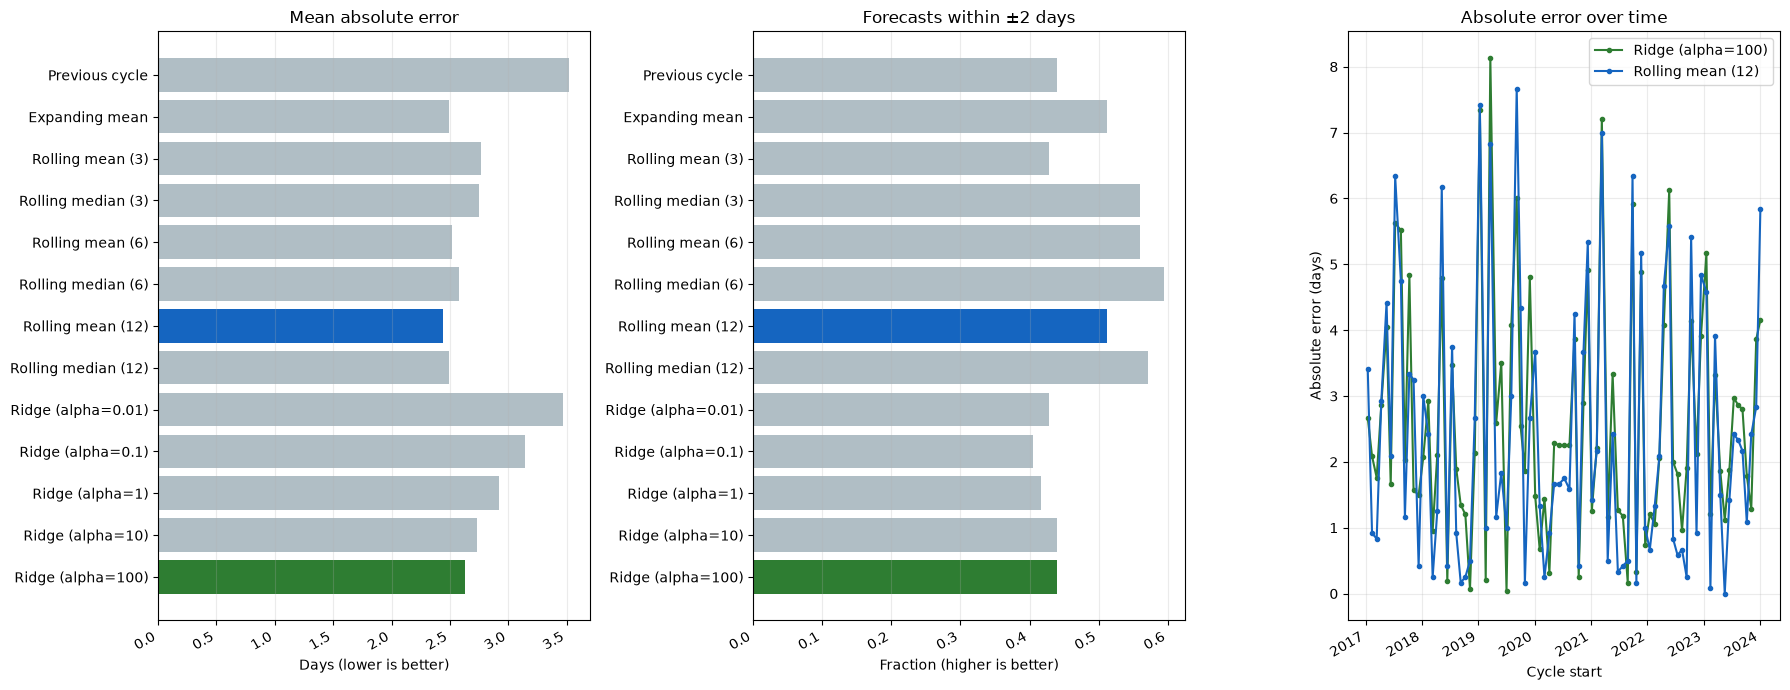

In [6]:
figure = plot_development_model_comparison(comparison=comparison)

## Check prediction uncertainty

These ranges use only mistakes from earlier development forecasts. Actual coverage says how often the completed cycle landed inside; width says how many days that reliability costs. The final holdout remains sealed.

In [7]:
uncertainty = evaluate_development_uncertainty(comparison=comparison)
uncertainty_report = render_development_uncertainty_markdown(evaluation=uncertainty)
display(Markdown(uncertainty_report))

# Development prediction uncertainty

> **Development only:** every interval used earlier forecast errors only; 
> the final temporal holdout remains sealed.

- Evaluated interval cycles: 72
- Calibration warmup: 12 forecasts
- Date range: 2018-01-08 to 2024-01-03

| Method | Target coverage | Actual coverage | Coverage gap | Mean width | Median width | Intervals |
|---|---:|---:|---:|---:|---:|---:|
| Ridge (alpha=100) | 50% | 50.0% | +0.0% | 4.29 days | 4.22 days | 72 |
| Ridge (alpha=100) | 80% | 84.7% | +4.7% | 9.25 days | 9.58 days | 72 |
| Ridge (alpha=100) | 90% | 91.7% | +1.7% | 11.45 days | 11.25 days | 72 |
| Rolling mean (12) | 50% | 56.9% | +6.9% | 4.15 days | 3.67 days | 72 |
| Rolling mean (12) | 80% | 81.9% | +1.9% | 8.87 days | 8.83 days | 72 |
| Rolling mean (12) | 90% | 93.1% | +3.1% | 12.61 days | 12.67 days | 72 |


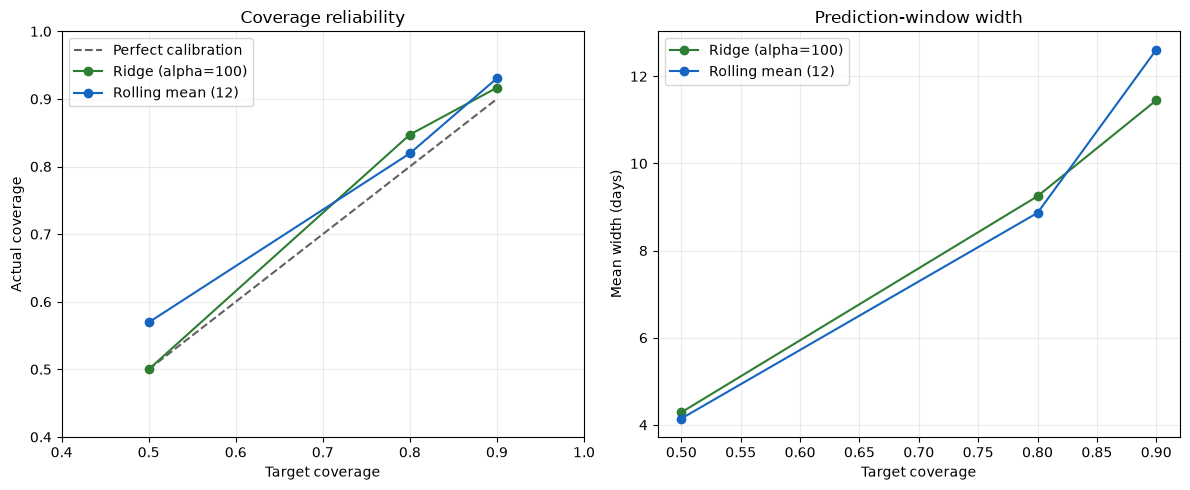

In [8]:
uncertainty_figure = plot_development_uncertainty(evaluation=uncertainty)

## Optionally save private results

The following cell is intentionally commented out. If enabled locally, it saves beneath `artifacts/`, which is ignored by Git. Do not redirect private output to a tracked directory.

In [9]:
# output_directory = project_root / "artifacts" / "model-comparison"
# output_directory.mkdir(parents=True, exist_ok=True)
# (output_directory / "development-model-comparison.md").write_text(
#     report,
#     encoding="utf-8",
# )
# figure.savefig(
#     output_directory / "development-model-comparison.png",
#     dpi=150,
#     bbox_inches="tight",
# )
# (output_directory / "development-uncertainty.md").write_text(
#     uncertainty_report,
#     encoding="utf-8",
# )
# uncertainty_figure.savefig(
#     output_directory / "development-uncertainty.png",
#     dpi=150,
#     bbox_inches="tight",
# )

## Interpretation guardrail

These are development results used to choose a model, not the final unbiased performance estimate. Do not inspect the final holdout until features, selection rules, and uncertainty evaluation are frozen.